# Graphical models using package `ggm`

This document is a tutorial for the **R** package `ggm`. Is a joint work by Giovanni Marchetti, Kayvan Sadeghi, Nanny Wermuth and Ilaria Carobbi.  


## Introduction

Graphical models are statistical models for data observed on a set of variables $Y_1, \dots, Y_d$, that specify a set of conditional and marginal independencies between the variables. The set of independencies is exactly determined by the structure of a graph having the variables as nodes. We describe here the functions available in the package `ggm`. The package `ggm` depends on the package `igraph`.


In [2]:
library(ggm)

Loading required package: igraph

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union


Attaching package: ‘ggm’

The following object is masked from ‘package:igraph’:

    pa



## Basic types of graph

In general, a graph $G$ is a mathematical object defined by a set of nodes (or vertices)  $V$ and by a set of edges $E$. In graphical models, graphs  are used to define relation between the variables. Thus, the nodes in $V$ are in 1-1 correspondence with the variables, and the edges in $E$ are pairs of distinct nodes $i$ and $j$ denoting an association between the variables $Y_i$ and $Y_j$. 

Edges can be undirected or directed. Undirected edges  $ij$ specify no order between $i$ and $j$. They are typically denoted by a line $ i-{\hspace{-15mu}}-j$, or a dashed line, or by a bi-directed arrow $i\longleftrightarrow j$. Directed edges $i \rightarrow j$ specify an order with $i$ coming before $j$. 

Graphs can be classified according to the type of edge they contain. The main types are:

* undirected graphs, containing only undirected edges
* directed graphs, containing only directed edges
* mixed graphs, containing both undirected and directed edges. The undirected edges may be of different types.

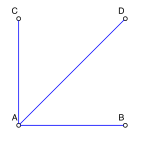

In [12]:
options(jupyter.plot_mimetypes = "image/svg+xml") 
options(repr.plot.width=2, repr.plot.height=2); par(cex = 0.6)
G = UG(~A*B + A*C + A*D)
drawGraph(G, layout = layout.grid)

In [14]:
G = DAG(Y ~ X + U, X ~ Z + U)
drawGraph(G, cex = 0.6)

ERROR: Error in drawGraph(G, cex = 0.6): unused argument (cex = 0.6)


In [ ]:

```{r echo = FALSE}
G = UG(~A*B + A*C + A*D)
drawGraph(G, tcltk = FALSE, layout = layout.grid)
```
*  directed graphs, containing only directed edges;
```{r echo = FALSE}
G = DAG(Y ~ X + U, X ~ Z + U)
lay = layout.grid(graph.adjacency(G))
plotGraph(G, tcltk = FALSE, layout = lay)
```
*  mixed graphs, containing both undirected and directed edges. The undirected edges may be of two different types. 
```{r echo= FALSE}
G <-
structure(c(0, 100, 0, 0, 0, 0, 1, 0, 100, 100, 0, 0, 0, 0, 1, 
0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10, 0, 0, 
0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 10, 0, 0, 0, 0, 0, 0, 
0, 0, 0, 0, 0, 0, 1, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 100, 0, 
0, 0, 0, 0, 100, 0, 0), .Dim = c(9L, 9L), .Dimnames = list(c("1", 
"2", "8", "9", "10", "11", "12", "13", "14"), c("1", "2", "8", 
"9", "10", "11", "12", "13", "14")))
plotGraph(G, tcltk = FALSE)
```
### Undirected graphs
An undirected graph contains only undirected edges. In statistics it is suitable to describe the associations between variables that are considered *on an equal standing*. 

Consider the following example. Let $Y, X, V, U$ be 4 variables  and suppose that  we define the undirected graph 


<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Y &    V\\ 
X &    U \\}; 
\path[-,font=\scriptsize,  thick] 
(m-1-1) edge   (m-2-1)
(m-1-2) edge   (m-2-2)
(m-1-1) edge   (m-2-2)
(m-2-1) edge (m-2-2);
\end{tikzpicture}
$$ 
-->
be 4 psychological variables measured on a sample of students.  The variables are $Y = $ state anxiety,  $X =$ state anger, $V=$ trait anxiety, $U=$ trait anger. 
with edges $VU, YU, UX, YX$. The graph may be defined by a square matrix, the *adjacency matrix*, that has the elements in positions $(i,j)$ and $(j,i)$ equal to  $1$ whenever the edge $ij$ is in $G$. This can be defined in `ggm` using the constructor function `UG`:
```{r}
G = UG(~ V*U + Y*U + U*X + Y*X)   
G
plotGraph(G, tcltk = FALSE, vertex.size = 15, vertex.label.cex = 1.5, layout = layout.grid)  
```
The output is a matrix whose row and column names are the nodes. The argument of the function `UG` is a *model formula* defining the edges of the graph by 4 two-way interaction terms. The same graph could be defined by a different model formula, with one two-factor interaction $VU$ and a three-factor interaction $YXU$:
```{r}
G = UG(~ V*U + Y*X*U)
G
plotGraph(G, tcltk = FALSE)  
```
The two subgraphs defined by the subsets $VU$ and $YXU$ are complete, that is, they have all the possible edges:
```{r}
a = c("U", "V") ; b = c("Y", "X", "U")
G[a,a]
G[b,b]
```
Moreover, the two subgraphs are maximal in the sense that they cannot be enlarged without losing  completeness. Therefore the two subsets  $VU$ and $YXU$ are called two \emph{cliques} of the graph. Finding the cliques of an undirected graph
is an NP-hard problem.

Sometimes we will need undirected graphs with bi-directed or dashed edges like for example   
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Y &    V\\ 
X &    U \\};
\path[<->,   dashed,   >= triangle 30] 
(m-1-1) edge   (m-1-2)
(m-1-2) edge   (m-2-2)
(m-1-1) edge   (m-2-1)
(m-2-1) edge (m-2-2);
\end{tikzpicture}
\qquad
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Y &    V\\ 
X &    U \\};
\path[-,thick,  dashed] 
(m-1-1) edge   (m-1-2)
(m-1-2) edge   (m-2-2)
(m-1-1) edge   (m-2-1)
(m-2-1) edge (m-2-2);
\end{tikzpicture}
$$ 
-->
To distinguish these graphs we code in their  adjacency matrix the edges  by a code 100 instead of a 1. Thus, with same function `UG`,  we define the two previous graphs by 
```{r}
G2 = makeMG(bg = UG(~ Y*V + V*U + U*X + Y*X))
G2
plotGraph(G2, tcltk = FALSE) 
```
### Directed acyclic graphs
A directed acyclic graph (a DAG for short) contains only directed edges. Each edge  
is a couple $(i,j)$ of nodes, defining the tail and the head of an arrow $i \rightarrow j$. Moreover in a DAG there are no cycles, i.e.,  is impossible 
starting from a node and following the direction of the arrows to get  back to the starting node. For example the following graph is a DAG.
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
X &   &   &    \\ 
  & Z & U & V \\ 
Y &   &   &     \\};
\path[->,thick, >= triangle 30] 
(m-1-1) edge   (m-2-2)
(m-3-1) edge   (m-2-2)
(m-2-2) edge   (m-2-3)
(m-1-1) edge   (m-2-4)
(m-3-1) edge   (m-2-3)
(m-2-3) edge (m-2-4);
\end{tikzpicture}
$$  
-->
 In a DAG each node $i$ has an  associated set of *parents* meaning the (possibly empty)  set $\mathrm{pa}(j)$ of  the nodes $i$ such that $i \rightarrow j$ is in $G$. Thus for example the parents of $V$ are $X$ and $U$, the parents of $U$ are $Z$ and $Y$, while  $X$ and $Y$ have no parents each. A directed acyclic graph is used in statistics to specify a data generating process, where each variable is directly dependent by some parent variables, and indirectly dependent via intermediate variables.  

A DAG $G$ may be defined by its *adjacency matrix*, a square matrix that has the elements in position $(i,j)$ equal to  $1$ whenever the edge $i \rightarrow j$  is in $G$. 

In \textsf{ggm} the previous DAG is defined by a constructor function `DAG` that
takes as arguments several model formulae giving the parents of each node (except, possibly, the nodes with no parents). The previous DAG is defined as follows: 
```{r}
D = DAG(V~ X + U, U ~ Z + Y, Z ~ X+Y)
plotGraph(D, tcltk = FALSE) 
```
A property of DAGs is that the nodes can be always reordered (not uniquely, in general) such that the parents are before the children. This is called the \emph{topological order} of the DAG. For instance 
```{r}
Do = topSort(D) 
Do
```
produces the adjacency matrix in  topological order, that turns out to be always upper triangular.

### Drawing graphs from right to left
The description of a DAG by a sequence of model formulae implies that each formula defines a node and its parents and that the parents are to the right of the symbol $\sim$. Even if this is the opposite of the topological order, sometimes it is convenient and therefore we shall draw a DAG from right to left. For example, the DAG defined above could be drawn as follows. 
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
     &   &   &  X  \\ 
  V  & U & Z &      \\ 
     &   &   &  Y   \\};
\path[<-,thick, >= triangle 30] 
(m-2-1) edge   (m-1-4)
(m-2-2) edge   (m-3-4)
(m-2-3) edge   (m-1-4)
(m-2-3) edge   (m-3-4)
(m-2-1) edge   (m-2-2)
(m-2-2) edge (m-2-3);
\end{tikzpicture}
$$  
-->
### Graphs with isolated nodes
A node is *isolated* if the set of its parents and children are empty. A DAG with an isolated node $X$ can be defined by introducing in the model formula a term $X \sim X$. For instance the graph 
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Z &  Y  &  X     \\}; 
\path[<-,thick, >= triangle 30] 
(m-1-1) edge   (m-1-2);
\end{tikzpicture}
$$     
is defined by 
```{r}
D = DAG(Z ~ Y, X~X) 
plotGraph(D, tcltk= FALSE, layout = layout.grid)
```
Some basic Gaussian graphical models
------------------------------------
We distinguish 5 types of graphical models
*  Covariance graph models
*  Concentration graph models
*  Regression graph models
*  Linear structural equation models

These models can be developed for both continuous or discrete data, but our discussion  will be limited to the first situation. 

In this case, the standard assumption is that the observed data are 
a random sample from a $d$-dimensional Gaussian distribution $Y =(Y_1, \dots, Y_d) \sim N(\mu, \Sigma)$, representing the population, where $\mu$ is the mean vector 
that, without loss of generality,  can be assumed to be zero, and where $\Sigma = [\sigma_{ij}]$ is a p.d. covariance matrix.  Often the Gaussian assumption is too strong, but as in linear regression, we can fit the  models with a set weaker assumptions provided that we include appropriate nonlinear terms (see the package \textbf{checklin}). Each model can be simply characterized by a set of linear constraints on parameters of the population. 

### Covariance graph models
A Gaussian covariance graph model for $Y$ is defined by zero constraints on the covariances as specified by the missing edges of  an undirected graph $G$. The model specifies that  
$$
 \sigma_{ij} = 0 \text{ whenever the edge } ij \text{ is not in } G.  
$$ 
In a Gaussian distribution $\sigma_{ij} = 0$ if and only the two variables $Y_i$ and $Y_j$ are marginally independent. Therefore a covariance graph model specifies an independence  $Y_i \ci Y_j$ for each missing edge $ij$. The model belongs to the class of linear in covariance structures (cf. Anderson, 1971).  

### Example
We analyze for a sample of 72 students, the covariance matrix among 4 variables  
measuring 4 different strategies to cope with stress. The variables are
$Y$, cognitive avoidance; $X$, vigilance; $V$, blunting and $U$, monitoring.
The data are contained in the package `ggm`. The following instructions compute the sample covariance matrix. 
```{r}
data(stress)
stress
```
Inspection of the sample correlation matrix 
```{r}
cov2cor(stress)
```
shows that a possible hypothesis to test is 
$\sigma_{XV} = \sigma_{YU} = 0$. This corresponds to a covariance graph model
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Y &    V\\ 
X &    U \\};
\path[-,thick,  dashed] 
(m-1-1) edge   (m-1-2)
(m-1-2) edge   (m-2-2)
(m-1-1) edge   (m-2-1)
(m-2-1) edge (m-2-2);
\end{tikzpicture}
$$
-->
This model can be fitted by maximum likelihood with
```{r}
G = makeMG(bg = UG(~ Y*X + X*U + U*V + V*Y))
plotGraph(G, tcltk = FALSE) 
fitCovGraph(G, stress, n = 72)
```
The output of the function is a list with components: `Shat`, the fitted covariance matrix, `dev`, the likelihood ratio statistic against the saturated model, i.e., the model with no restrictions on the covariances, and \code{it}, the number of iterations of the algorithm. The fit for the \code{stressful} data is almost perfect.  

Now we look at another example with a sample of simulated data from a Gaussian distribution with mean zero and covariance matrix
$$
V = \begin{bmatrix}
1 & .8&  0 &  0 \\ 
.8& 1 &  .5 &  0\\
 0& .5 &  1 &  -0.4\\
 0& 0 &  -0.4 &  1\\
\end{bmatrix} 
$$  
The structure of the covariance matrix implies a covariance graph 
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=2em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
X &    Y & Z & U\\}; 
\path[-,thick,  dashed] 
(m-1-1) edge   (m-1-2)
(m-1-2) edge   (m-1-3)
(m-1-3) edge   (m-1-4);
\end{tikzpicture}
$$
-->
that is a 4-chain. The data are simulated using `mvrnorm` from package `MASS`.  
```{r}
V = matrix(c(1, .8, 0, 0, 
            .8, 1, .5, 0,
             0, .5, 1, -0.4,
             0, 0, -0.4, 1), 4, 4) 
mu = c(0,0,0,0)

library(MASS)
X = mvrnorm(100, mu, V)
X = data.frame(X)
names(X) = c("X", "Y", "Z", "U") 
cov(X)
```
Notice that we first convert the matrix of simulated data to a data frame with appropriate variable names. We can fit the 4-chain from the dataframe \code{X} with 
```{r}
G = UG(~ X*Y + Y*Z + Z*U)
plotGraph(G, tcltk = FALSE, layout = layout.grid) 
fitCovGraph(G, data = X)
```
### Concentration graph models
A Gaussian concentration graph model for a random vector $Y$ is defined by zero constraints on the inverse of the covariance matrix $\Sigma$. This is called the *concentration matrix* and is denoted by $\Sigma^{-1} = [\sigma^{ij}]$. Given an undirected graph $G$ this model specifies that 
$$
\sigma^{ij} = 0 \text{ whenever the edge } ij \text{ is not in } G.
$$ 
If $Y$ has a Gaussian distribution, the constraint $\sigma^{ij} = 0$ is shown to be equivalent to the \emph{conditional independence } $Y_i \ci Y_j | $ given all the remaining variables. Thus the concentration graph model specifies a set of pairwise 
conditional independencies for each missing edge in the graph.
 
An undirected graphs $G$ is defined by a set of nodes, usually denoted by integers $i = 1, \dots, d$, and by a set $E$ of edges, described by pairs $\{i,j\}$ of nodes. The \emph{set of missing edges} is the complementary set of $E$. A simple representation of the graph is given by its \emph{adjacency matrix}. A concentration graph model is also called a *covariance selection model*; see Dempster (1972).   

A Gaussian undirected graph model for a $d$-dimensional random vector $Y=(Y_1, \dots, Y_d)$   is defined by a family of Gaussian distributions with mean vector zero and a $d\times d$ covariance matrix $\Sigma = [\sigma_{ij}]$  such that its inverse  $\Sigma^{-1}= [\sigma^{ij}]$ satisfies
 $$
 \sigma^{ij} = 0 \text{ whenever } i-{\mkern-15mu}-j \text{ is  not in } G
 $$        
The inverse of the covariance matrix is called a *concentration matrix* and therefore the model specifies zero constraints on the concentrations. The model is sometimes called a *covariance selection model* (Dempster) or
*concentration graph model* (Cox and Wermuth, 1996).

The concentration graph model specifies a set of conditional independencies: for each missing edge $i-{\mkern-15mu}-j$, the variables $Y_i$ and $Y_j$ are independent given all the remaining variables  $Y_{V \setminus ij}$. 

### Example    
We analyze a covariance matrix for a sample of  684 female college students, concerning 4 variables on anxiety and anger. The 4 variables are: $Y$ = state anxiety, $X$ = state anger, $V$ = trait anxiety, $U$ = trait anger. The sample covariance matrix is as follows
```{r}
data(anger)
anger
```
A preliminary analysis is that of computing the marginal and partial correlation matrices. The function `correlations` stores the marginal and partial correlations in the lower and upper triangle of a matrix, respectively: 
```{r}
correlations(anger)
```
The almost zero partial correlations $\hat \rho_{YU.XV}$ and $\hat\rho_{XV.YU}$ suggest the concentration graph model
<!--
$$
 \begin{tikzpicture}[description/.style={fill=white,inner sep=2pt}  ] 
\matrix (m) [matrix of math nodes, row sep=3em, column sep=3em, text height=1.0ex, text depth=0.0ex, nodes = {outer sep = 1pt}] { 
Y &    V\\ 
X &    U \\};
\path[-,thick] 
(m-1-1) edge   (m-1-2)
(m-1-2) edge   (m-2-2)
(m-1-1) edge   (m-2-1)
(m-2-1) edge (m-2-2);
\end{tikzpicture}
$$
-->
This can be fitted by ML using the function `fitConGraph` as follows. 
```{r}
G = UG(~ Y*V + V*U + U*X+X*Y)
plotGraph(G, tcltk = FALSE) 
ml = fitConGraph(amat = G, S, n = 684)
ml
```
The output is the same of the function `fitConGraph` where `Shat` is the fitted covariance matrix $\hat \Sigma = [\hat \sigma_{ij}]$. The fitted concentration matrix is simply the inverse $\hat \Sigma^{-1}$ and we can verify that the two conditions of the maximum likelihood estimates are verified, that is (a)  the concentrations corresponding to the missing edges are zero:
```{r}
round(solve(ml$Shat),4)
```
and (b) the fitted covariances corresponding to the edges present coincide with the
sample covariances. 

### Directed acyclic graph models      
A Gaussian directed acyclic  graph model for a $d$-dimensional random vector $Y$   is defined by the recursive equations 
$$
Y = B Y + \epsilon, \text{ where } \epsilon \sim N(0, \Delta)
$$
where $\epsilon$ is a vector of independent residuals with a diagonal covariance matrix $\Delta$ and $B = [\beta_{ij}]$ is a matrix of coefficients  such that 
$$
\beta_{ij} = 0     \text{ whenever } i \leftarrow j \text{ is not in } G. 
$$   
Therefore the concentration and covariance matrices of $Y$ are
$$
\Sigma^{-1} = A^T \Delta^{-1} A, \quad \Sigma = A^{-1}\Delta A^T
$$                                   
where $A = I-B$.

The model specifies a set of conditional independencies between $Y_i$ and $Y_j$ given all the remaining variables  $Y_{V \setminus ij}$ if the edge  $\{i,j\}$ is missing.

In [1]:
library(ggm)

Loading required package: igraph

Attaching package: ‘igraph’

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union


Attaching package: ‘ggm’

The following object is masked from ‘package:igraph’:

    pa



In [2]:
? ggm
